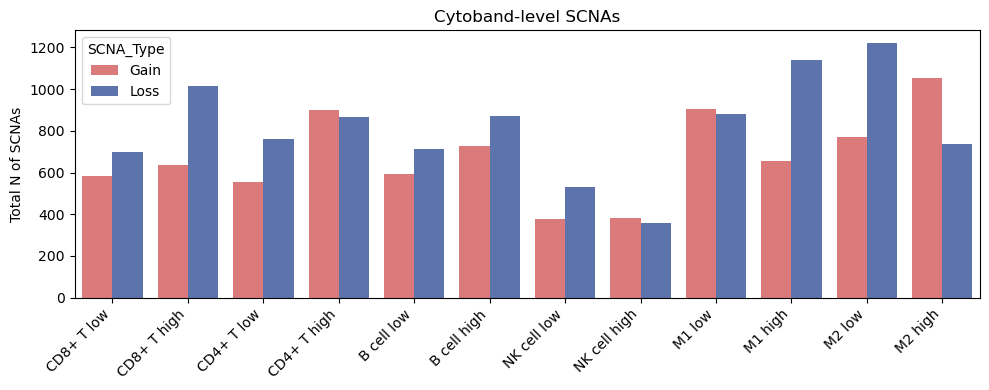

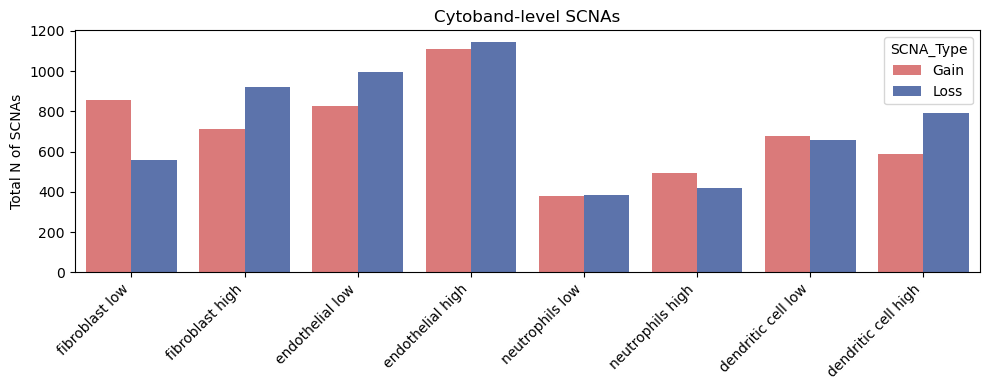

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob

# Folder where your *_table.csv cytoband-level files live
folder = "./"
table_files = sorted(glob(os.path.join(folder, "*_table.csv")))

# Rename mapping (same as original)
rename_map = {
    "CD8_tcells": "CD8+ T",
    "CD4_tcells": "CD4+ T",
    "B_cells": "B cell",
    "NK_cells": "NK cell",
    "Macrophage_M1": "M1",
    "Macrophage_M2": "M2",
    "Fibroblasts": "fibroblast",
    "Endothelium": "endothelial",
    "Neutrophils": "neutrophils",
    "Dendritic_cells": "dendritic cell"
}

# Group ordering (same as original)
group1_order = [
    "CD8+ T low", "CD8+ T high", "CD4+ T low", "CD4+ T high", 
    "B cell low", "B cell high",
    "NK cell low", "NK cell high", "M1 low", "M1 high",
    "M2 low", "M2 high"
]

group2_order = [
    "fibroblast low", "fibroblast high", "endothelial low", "endothelial high",
    "neutrophils low", "neutrophils high", "dendritic cell low", "dendritic cell high"
]

# How to label bars
def format_label(raw, status):
    base = rename_map.get(raw, raw.replace("_", " ").replace("cells", "").replace("cell", "").strip())
    suffix = "low" if status == "cold" else "high"
    return f"{base} {suffix}"

# Collect plot data
plot_data = []

for file_path in table_files:
    raw = os.path.basename(file_path).replace("_table.csv", "")
    if raw not in rename_map:
        continue  # skip any unrelated files

    df = pd.read_csv(file_path)
    df = df[df["AllHits"].notna()]

    # Immune cold
    df_cold = df[df["AllHits"].str.contains("ImmuneCold")]
    gain_cold = df_cold["AllHits"].str.contains("Gain").sum()
    loss_cold = df_cold["AllHits"].str.contains("Loss").sum()
    label_cold = format_label(raw, "cold")
    plot_data.append({"CellType": label_cold, "SCNA_Type": "Gain", "Count": gain_cold})
    plot_data.append({"CellType": label_cold, "SCNA_Type": "Loss", "Count": loss_cold})

    # Immune hot
    df_hot = df[df["AllHits"].str.contains("ImmuneHot")]
    gain_hot = df_hot["AllHits"].str.contains("Gain").sum()
    loss_hot = df_hot["AllHits"].str.contains("Loss").sum()
    label_hot = format_label(raw, "hot")
    plot_data.append({"CellType": label_hot, "SCNA_Type": "Gain", "Count": gain_hot})
    plot_data.append({"CellType": label_hot, "SCNA_Type": "Loss", "Count": loss_hot})

# Create DataFrame
plot_df = pd.DataFrame(plot_data)

# Plot Group 1 - Cytoband Level
plt.figure(figsize=(10, 4))
sns.barplot(
    data=plot_df[plot_df["CellType"].isin(group1_order)],
    x="CellType", y="Count", hue="SCNA_Type",
    order=group1_order,
    palette={"Gain": "#EA6A6A", "Loss": "#4F6DB8"}  # updated color
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Total N of SCNAs")
plt.xlabel("")
plt.title("Cytoband-level SCNAs")
plt.tight_layout()
plt.savefig("fig4a_cytoband.pdf", format="pdf", bbox_inches="tight")
plt.show()

# Plot Group 2 - Cytoband Level
plt.figure(figsize=(10, 4))
sns.barplot(
    data=plot_df[plot_df["CellType"].isin(group2_order)],
    x="CellType", y="Count", hue="SCNA_Type",
    order=group2_order,
    palette={"Gain": "#EA6A6A", "Loss": "#4F6DB8"}
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Total N of SCNAs")
plt.xlabel("")
plt.title("Cytoband-level SCNAs")
plt.tight_layout()
plt.savefig("fig4b_cytoband.pdf", format="pdf", bbox_inches="tight")
plt.show()

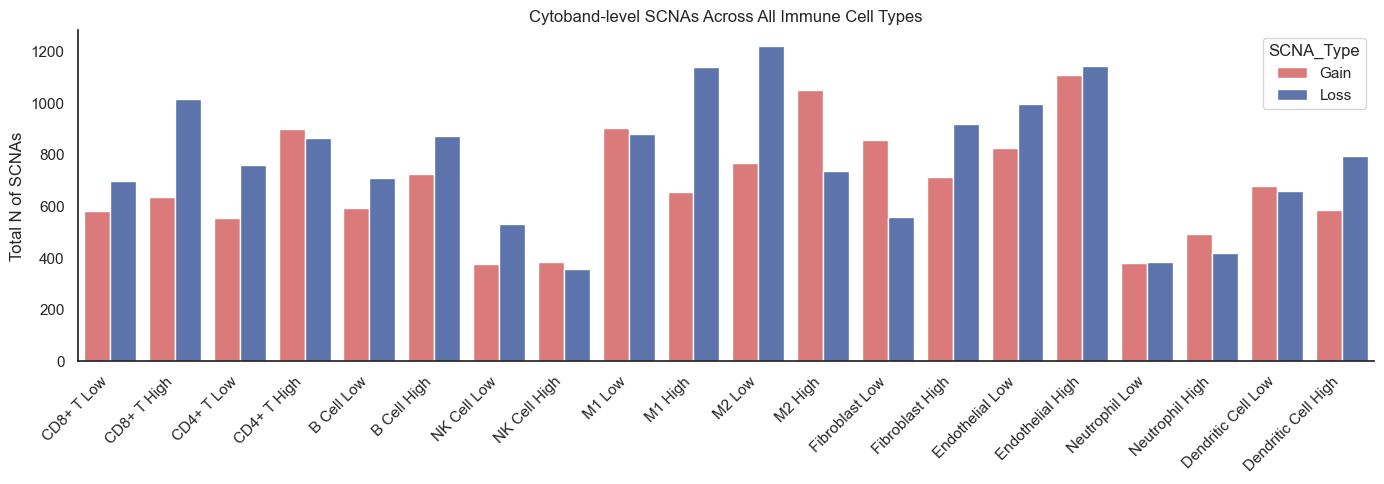

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob

# ── FOLDER WITH CYTOBAND-LEVEL *_table.csv FILES ─────────────────────────────
folder = "./"
table_files = sorted(glob(os.path.join(folder, "*_table.csv")))

# ── DISPLAY NAMES (CAPITAL-CASED) ────────────────────────────────────────────
rename_map = {
    "CD8_tcells"     : "CD8+ T",
    "CD4_tcells"     : "CD4+ T",
    "B_cells"        : "B Cell",
    "NK_cells"       : "NK Cell",
    "Macrophage_M1"  : "M1",
    "Macrophage_M2"  : "M2",
    "Fibroblasts"    : "Fibroblast",
    "Endothelium"    : "Endothelial",
    "Neutrophils"    : "Neutrophil",
    "Dendritic_cells": "Dendritic Cell",
}

# ── X-AXIS ORDER (MATCHES ARM-LEVEL PLOT) ────────────────────────────────────
celltype_order = [
    "CD8+ T Low", "CD8+ T High",
    "CD4+ T Low", "CD4+ T High",
    "B Cell Low", "B Cell High",
    "NK Cell Low", "NK Cell High",
    "M1 Low", "M1 High", "M2 Low", "M2 High",
    "Fibroblast Low", "Fibroblast High",
    "Endothelial Low", "Endothelial High",
    "Neutrophil Low", "Neutrophil High",
    "Dendritic Cell Low", "Dendritic Cell High",
]

# ── CONSISTENT COLOURS ───────────────────────────────────────────────────────
palette = {"Gain": "#EA6A6A", "Loss": "#4F6DB8"}

# ── HELPER ───────────────────────────────────────────────────────────────────
def format_label(raw_name: str, status: str) -> str:
    base   = rename_map.get(raw_name, raw_name.replace("_", " ").title())
    suffix = "Low" if status == "cold" else "High"
    return f"{base} {suffix}"

# ── COLLECT DATA ─────────────────────────────────────────────────────────────
rows = []

for fp in table_files:
    raw = os.path.basename(fp).replace("_table.csv", "")
    if raw not in rename_map:
        continue

    df = pd.read_csv(fp)
    df = df[df["AllHits"].notna()]

    # Immune-cold
    cold = df[df["AllHits"].str.contains("ImmuneCold")]
    rows.extend([
        {"CellType": format_label(raw, "cold"), "SCNA_Type": "Gain",
         "Count": cold["AllHits"].str.contains("Gain").sum()},
        {"CellType": format_label(raw, "cold"), "SCNA_Type": "Loss",
         "Count": cold["AllHits"].str.contains("Loss").sum()},
    ])

    # Immune-hot
    hot = df[df["AllHits"].str.contains("ImmuneHot")]
    rows.extend([
        {"CellType": format_label(raw, "hot"), "SCNA_Type": "Gain",
         "Count": hot["AllHits"].str.contains("Gain").sum()},
        {"CellType": format_label(raw, "hot"), "SCNA_Type": "Loss",
         "Count": hot["AllHits"].str.contains("Loss").sum()},
    ])

plot_df = pd.DataFrame(rows)

# ── PLOT ─────────────────────────────────────────────────────────────────────
sns.set_theme(style="white")                # remove background grid
plt.figure(figsize=(14, 5))
ax = sns.barplot(
    data   = plot_df,
    x      = "CellType",
    y      = "Count",
    hue    = "SCNA_Type",
    order  = celltype_order,
    palette= palette
)
ax.grid(False)                              # ensure no grid lines
sns.despine()
plt.xticks(rotation=45, ha="right")
plt.ylabel("Total N of SCNAs")
plt.xlabel("")
plt.title("Cytoband-level SCNAs Across All Immune Cell Types")
plt.tight_layout()
plt.savefig("fig4_combined_cytoband.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [2]:
# Group by CellType and SCNA_Type to get detailed counts
cytoband_scna_counts = plot_df.groupby(["CellType", "SCNA_Type"])["Count"].sum().reset_index()

# Print the SCNA count table
print("Cytoband-level SCNA counts per cell type × immune status × SCNA type:")
print(cytoband_scna_counts)

Cytoband-level SCNA counts per cell type × immune status × SCNA type:
               CellType SCNA_Type  Count
0           B Cell High      Gain    725
1           B Cell High      Loss    872
2            B Cell Low      Gain    594
3            B Cell Low      Loss    712
4           CD4+ T High      Gain    901
5           CD4+ T High      Loss    867
6            CD4+ T Low      Gain    556
7            CD4+ T Low      Loss    762
8           CD8+ T High      Gain    638
9           CD8+ T High      Loss   1017
10           CD8+ T Low      Gain    582
11           CD8+ T Low      Loss    700
12  Dendritic Cell High      Gain    587
13  Dendritic Cell High      Loss    794
14   Dendritic Cell Low      Gain    680
15   Dendritic Cell Low      Loss    660
16     Endothelial High      Gain   1110
17     Endothelial High      Loss   1146
18      Endothelial Low      Gain    828
19      Endothelial Low      Loss    996
20      Fibroblast High      Gain    715
21      Fibroblast High     

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob

# === Folder and rename map ===
folder = "./"  # update if needed
rename_map = {
    "CD8_tcells": "CD8+ T", "CD4_tcells": "CD4+ T",
    "B_cells": "B cell", "NK_cells": "NK cell",
    "Macrophage_M1": "M1", "Macrophage_M2": "M2",
    "Fibroblasts": "fibroblast", "Endothelium": "endothelial",
    "Neutrophils": "neutrophils", "Dendritic_cells": "dendritic cell"
}

# === Tumor type → tumor group ===
tumor_group_map = {
    "UCEC.MSI": "Gyn", "UCEC.MSS": "Gyn", "OV": "Gyn", "CESC": "Gyn",
    "LUSC": "Squamous", "HNSC.HPVneg": "Squamous", "ESCA.SC": "Squamous",
    "BLCA": "NC-Derived", "BRCA.neg": "NC-Derived", "BRCA.pos": "NC-Derived", "PRAD": "NC-Derived",
    "GBM": "NC-Derived", "LGG": "NC-Derived", "SKCM": "NC-Derived", "UVM": "NC-Derived",
    "LUAD": "Adeno", "LIHC": "Adeno", "ACC": "Adeno", "MESO": "Adeno",
    "COADREAD.MSI": "GI", "COADREAD.MSS": "GI", "ESCA.AD": "GI", "STAD": "GI", "PAAD": "GI",
    "KICH": "Kidney", "KIRC": "Kidney", "KIRP": "Kidney",
    "PCPG": "Other", "SARC": "Other", "TGCT": "Other", "UCS": "Other"
}

# === Color palette from legend ===
tumor_group_palette = {
    "Adeno": "#8c4340",
    "GI": "#f5c344",
    "Gyn": "#7f61a4",
    "Kidney": "#5c76b3",
    "NC-Derived": "#a3453d",
    "Other": "#7fa5a6",
    "Squamous": "#4f9d4d"
}

# === Plotting groups ===
group1 = ["CD8+ T", "B cell", "NK cell", "M1", "M2"]
group2 = ["Fibroblast", "Endothelial", "eutrophils", "dendritic cell"]
immune_statuses = [("ImmuneCold", "low"), ("ImmuneHot", "high")]

def format_label(raw, status):
    base = rename_map.get(raw, raw)
    suffix = "low" if status == "cold" else "high"
    return f"{base} {suffix}"

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob
from matplotlib.backends.backend_pdf import PdfPages

# === CONFIGURATION ===
folder = "./"  # Folder with cytoband-level *_table.csv files
table_files = sorted(glob(os.path.join(folder, "*_table.csv")))

# Rename map
rename_map = {
    "CD8_tcells": "CD8+ T",
    "CD4_tcells": "CD4+ T",
    "B_cells": "B cell",
    "NK_cells": "NK cell",
    "Macrophage_M1": "M1",
    "Macrophage_M2": "M2",
    "Fibroblasts": "Fibroblast",
    "Endothelium": "Endothelial",
    "Neutrophils": "Neutrophils",
    "Dendritic_cells": "Dendritic cell"
}

# Combined plotting order
celltype_order = [
    "CD8+ T low", "CD8+ T high",
    "CD4+ T low", "CD4+ T high",
    "B cell low", "B cell high",
    "NK cell low", "NK cell high",
    "M1 low", "M1 high", "M2 low", "M2 high",
    "fibroblast low", "fibroblast high",
    "endothelial low", "endothelial high",
    "neutrophils low", "neutrophils high",
    "dendritic cell low", "dendritic cell high"
]

# Tumor group mapping
tumor_group_map = {
    "OV": "Gyn", "UCEC": "Gyn", "CESC": "Gyn",
    "KIRC": "Kidney", "KIRP": "Kidney", "KICH": "Kidney",
    "LUAD": "Adeno", "LUSC": "Squamous", "ESCA": "Other",
    "STAD": "GI", "COAD": "GI", "READ": "GI",
    "SKCM": "NC-Derived", "GBM": "NC-Derived", "LGG": "NC-Derived",
    "HNSC": "Squamous", "BLCA": "Other", "PAAD": "GI"
}

tumor_group_order = ["Adeno", "GI", "Gyn", "Kidney", "NC-Derived", "Other", "Squamous"]

# Format labels
def format_label(raw, status):
    base = rename_map.get(raw, raw.replace("_", " ").replace("cells", "").replace("cell", "").strip())
    suffix = "low" if status == "cold" else "high"
    return f"{base} {suffix}"

# Collect data
plot_data = []

for file_path in table_files:
    raw = os.path.basename(file_path).replace("_table.csv", "")
    if raw not in rename_map:
        continue

    df = pd.read_csv(file_path)
    df = df[df["AllHits"].notna()]
    if "TumorType" not in df.columns:
        continue
    df["TumorGroup"] = df["TumorType"].map(tumor_group_map)

    for immune_tag, status in [("ImmuneCold", "cold"), ("ImmuneHot", "hot")]:
        df_sub = df[df["AllHits"].str.contains(immune_tag)]
        label = format_label(raw, status)

        for tumor_group in df_sub["TumorGroup"].dropna().unique():
            df_group = df_sub[df_sub["TumorGroup"] == tumor_group]
            gain_count = df_group["AllHits"].str.contains("Gain").sum()
            loss_count = df_group["AllHits"].str.contains("Loss").sum()
            plot_data.append({
                "TumorGroup": tumor_group,
                "CellType": label,
                "SCNA_Type": "Gain",
                "Count": gain_count
            })
            plot_data.append({
                "TumorGroup": tumor_group,
                "CellType": label,
                "SCNA_Type": "Loss",
                "Count": loss_count
            })

df_plot = pd.DataFrame(plot_data)

# === PLOT: All tumor groups into one multi-page PDF ===
with PdfPages("SCNA_Cytoband_ByTumorGroup.pdf") as pdf:
    for tumor in tumor_group_order:
        plt.figure(figsize=(14, 4))
        df_sub = df_plot[df_plot["TumorGroup"] == tumor]

        sns.barplot(
            data=df_sub,
            x="CellType", y="Count", hue="SCNA_Type",
            order=celltype_order,
            palette={"Gain": "#EA6A6A", "Loss": "#4F6DB8"}
        )
        plt.title(f"Cytoband-level SCNAs – {tumor}")
        plt.ylabel("Total SCNAs")
        plt.xlabel("")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        pdf.savefig()
        plt.close()

print("✅ Saved: SCNA_Cytoband_ByTumorGroup.pdf")

✅ Saved: SCNA_Cytoband_ByTumorGroup.pdf


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob
from matplotlib.backends.backend_pdf import PdfPages

# === CONFIGURATION ============================================================
folder = "./"                     # folder with *arm*-level *_table.csv files
table_files = sorted(glob(os.path.join(folder, "*_table.csv")))

# unified colours
SCNA_PALETTE = {"Gain": "#EA6A6A", "Loss": "#4F6DB8"}

# display names (capital-cased)
rename_map = {
    "CD8_tcells"     : "CD8+ T",
    "CD4_tcells"     : "CD4+ T",
    "B_cells"        : "B Cell",
    "NK_cells"       : "NK Cell",
    "Macrophage_M1"  : "M1",
    "Macrophage_M2"  : "M2",
    "Fibroblasts"    : "Fibroblast",
    "Endothelium"    : "Endothelial",
    "Neutrophils"    : "Neutrophil",
    "Dendritic_cells": "Dendritic Cell",
}

# x-axis order (same as cytoband plot)
celltype_order = [
    "CD8+ T Low", "CD8+ T High",
    "CD4+ T Low", "CD4+ T High",
    "B Cell Low", "B Cell High",
    "NK Cell Low", "NK Cell High",
    "M1 Low", "M1 High", "M2 Low", "M2 High",
    "Fibroblast Low", "Fibroblast High",
    "Endothelial Low", "Endothelial High",
    "Neutrophil Low", "Neutrophil High",
    "Dendritic Cell Low", "Dendritic Cell High",
]

# tumour-group mapping / order
tumor_group_map = {
    "OV": "Gyn", "UCEC": "Gyn", "CESC": "Gyn",
    "KIRC": "Kidney", "KIRP": "Kidney", "KICH": "Kidney",
    "LUAD": "Adeno", "LUSC": "Squamous", "ESCA": "Other",
    "STAD": "GI", "COAD": "GI", "READ": "GI",
    "SKCM": "NC-Derived", "GBM": "NC-Derived", "LGG": "NC-Derived",
    "HNSC": "Squamous", "BLCA": "Other", "PAAD": "GI",
}
tumor_group_order = ["Adeno", "GI", "Gyn", "Kidney", "NC-Derived", "Other", "Squamous"]

# helper: add Low/High suffix, keep caps consistent
def format_label(raw_name, status):
    base = rename_map.get(raw_name, raw_name.replace("_", " ").title())
    suffix = "Low" if status == "cold" else "High"
    return f"{base} {suffix}"

# === BUILD PLOTTING DATA ======================================================
plot_data = []

for fp in table_files:
    raw = os.path.basename(fp).replace("_table.csv", "")
    if raw not in rename_map:
        continue

    df = pd.read_csv(fp)
    df = df[df["AllHits"].notna()]
    if "TumorType" not in df.columns:
        continue

    df["TumorGroup"] = df["TumorType"].map(tumor_group_map)

    for tag, status in [("ImmuneCold", "cold"), ("ImmuneHot", "hot")]:
        df_sub = df[df["AllHits"].str.contains(tag)]
        label  = format_label(raw, status)

        for tg in df_sub["TumorGroup"].dropna().unique():
            df_grp = df_sub[df_sub["TumorGroup"] == tg]
            plot_data.extend([
                {"TumorGroup": tg, "CellType": label, "SCNA_Type": "Gain",
                 "Count": df_grp["AllHits"].str.contains("Gain").sum()},
                {"TumorGroup": tg, "CellType": label, "SCNA_Type": "Loss",
                 "Count": df_grp["AllHits"].str.contains("Loss").sum()},
            ])

df_plot = pd.DataFrame(plot_data)

# === PLOT TO MULTI-PAGE PDF ===================================================
with PdfPages("SCNA_Arm_ByTumorGroup.pdf") as pdf:
    for tumor in tumor_group_order:
        plt.figure(figsize=(14, 4))
        sns.barplot(
            data=df_plot[df_plot["TumorGroup"] == tumor],
            x="CellType", y="Count", hue="SCNA_Type",
            order=celltype_order, palette=SCNA_PALETTE
        )
        plt.title(f"Arm-level SCNAs – {tumor}")
        plt.ylabel("Total SCNAs")
        plt.xlabel("")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        pdf.savefig()
        plt.close()

print("✅ Saved: SCNA_Arm_ByTumorGroup.pdf")

✅ Saved: SCNA_Arm_ByTumorGroup.pdf


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Read the regression results
df = pd.read_csv('/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/bulk seq/TCGA_Deconvolutions_CNV_IS/Cytoband/Outputs/PAAD_is0.3_cytobandcnv_continuous0.2_regression.csv')

# Filter for 1q cytobands
df_1q = df[df['ChrArm'] == 'Chr1q'].copy()

# Sort by p-value to find most significant associations
df_1q = df_1q.sort_values('P_val')

# Print most significant cytobands
print("\nMost significant 1q cytobands in PAAD (sorted by p-value):")
print(df_1q[['Cytoband', 'Event', 'Coefficients', 'P_val']].head(10))

# Create visualization for top significant cytobands
plt.figure(figsize=(15, 8))

# Plot coefficients for each cytoband
sns.barplot(data=df_1q, 
            x='Cytoband', 
            y='Coefficients',
            hue='Event',
            order=df_1q['Cytoband'].unique())

plt.xticks(rotation=45, ha='right')
plt.title('M1 Macrophage IS Scores by 1q Cytoband in PAAD')
plt.xlabel('1q Cytoband')
plt.ylabel('IS Score')
plt.legend(title='CNV Event')
plt.tight_layout()

# Save the plot
plt.savefig('PAAD_m1_macrophages_1q_cytobands.png', dpi=300, bbox_inches='tight')
plt.close()

# Print cytobands with negative coefficients (associated with low M1 macrophages)
print("\n1q cytobands associated with low M1 macrophages (negative coefficients):")
negative_associations = df_1q[df_1q['Coefficients'] < 0].sort_values('P_val')
print(negative_associations[['Cytoband', 'Event', 'Coefficients', 'P_val']].head(10))


Most significant 1q cytobands in PAAD (sorted by p-value):
    Cytoband Event  Coefficients     P_val
64    1q21.2  Gain     -4.032378  0.030126
66    1q21.1  Gain     -4.456189  0.030521
74    1q23.1  Gain     -3.249993  0.054120
70    1q21.3  Gain     -2.847737  0.058690
119     1q44  Loss     -4.951079  0.067992
72      1q22  Gain     -2.665676  0.073395
117     1q43  Loss     -4.769627  0.081655
82    1q24.2  Gain     -2.997546  0.091005
80    1q24.1  Gain     -2.963752  0.097583
78    1q23.3  Gain     -2.918723  0.103123

1q cytobands associated with low M1 macrophages (negative coefficients):
    Cytoband Event  Coefficients     P_val
64    1q21.2  Gain     -4.032378  0.030126
66    1q21.1  Gain     -4.456189  0.030521
74    1q23.1  Gain     -3.249993  0.054120
70    1q21.3  Gain     -2.847737  0.058690
119     1q44  Loss     -4.951079  0.067992
72      1q22  Gain     -2.665676  0.073395
117     1q43  Loss     -4.769627  0.081655
82    1q24.2  Gain     -2.997546  0.091005
80    

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Read M1 macrophage data
m1_df = pd.read_csv('/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/bulk seq/Top_xCell_Continuous_Cytoband_Hits/Macrophage_M1_table.csv')

# Filter for PAAD and 1q cytobands
paad_1q = m1_df[(m1_df['TumorType'] == 'PAAD') & (m1_df['Cytoband'].str.startswith('1q'))].copy()

# Filter for significant associations (p < 0.1)
significant = paad_1q[paad_1q['P_val'] < 0.1].copy()

# Sort by p-value
significant = significant.sort_values('P_val')

# Save significant cytobands to CSV
significant.to_csv('PAAD_significant_1q_cytobands.csv', index=False)

# Print significant cytobands with all columns
print("\nSignificant 1q cytobands in PAAD associated with M1 macrophages (p < 0.1):")
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)  # Don't wrap wide tables
print(significant.head(10))

# Create visualization
plt.figure(figsize=(15, 8))

# Plot Z-scores for each cytoband
sns.barplot(data=significant, 
            x='Cytoband', 
            y='Z_val',
            hue='Event',
            order=significant['Cytoband'].unique())

plt.xticks(rotation=45, ha='right')
plt.title('M1 Macrophage Z-scores for Significant 1q Cytobands in PAAD')
plt.xlabel('1q Cytoband')
plt.ylabel('M1 Macrophage Z-score')
plt.legend(title='CNV Event')
plt.tight_layout()

# Save the plot
plt.savefig('PAAD_m1_macrophages_significant_cytobands.png', dpi=300, bbox_inches='tight')
plt.close()

# Print cytobands with negative Z-scores (associated with low M1 macrophages) with all columns
print("\nSignificant cytobands associated with low M1 macrophages:")
negative_associations = significant[significant['Z_val'] < 0].sort_values('Z_val')
print(negative_associations.head(10))

# Save negative associations to CSV
negative_associations.to_csv('PAAD_negative_M1_associations.csv', index=False)


Significant 1q cytobands in PAAD associated with M1 macrophages (p < 0.1):
           MergeBy TumorType Cytoband Event     Z_val     P_val  ImmuneCold  \
32306  PAAD_1q21.1      PAAD   1q21.1  Gain -2.356488  0.018449        True   
32308  PAAD_1q21.2      PAAD   1q21.2  Gain -2.331014  0.019753        True   
32320  PAAD_1q24.1      PAAD   1q24.1  Gain -1.976999  0.048042        True   
32322  PAAD_1q24.2      PAAD   1q24.2  Gain -1.969321  0.048916        True   
32310  PAAD_1q21.3      PAAD   1q21.3  Gain -1.890975  0.058628        True   
32314  PAAD_1q23.1      PAAD   1q23.1  Gain -1.879432  0.060186        True   
32312    PAAD_1q22      PAAD     1q22  Gain -1.853158  0.063860        True   
32316  PAAD_1q23.2      PAAD   1q23.2  Gain -1.831008  0.067099        True   
32318  PAAD_1q23.3      PAAD   1q23.3  Gain -1.823708  0.068196        True   
32324  PAAD_1q24.3      PAAD   1q24.3  Gain -1.721895  0.085088        True   

       ImmuneHot  has_diff_signs  Signif  ColdHits  Ho

In [18]:
import pandas as pd
from scipy.stats import norm
import numpy as np

# === Load macrophage M1 cold Z-score matrix ===
path = "/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/bulk seq/Top_xCell_Continuous_Cytoband_Hits/Macrophage_M1_COLD_heatmap_matrix.csv"
df = pd.read_csv(path, index_col=0)

# === Get Z-scores for PAAD row ===
z_scores = df.loc["PAAD"]

# === Convert Z-scores to two-tailed p-values ===
p_values = norm.sf(np.abs(z_scores)) * 2  # survival function = 1 - CDF

# === Combine into one dataframe ===
results_df = pd.DataFrame({
    "Cytoband": z_scores.index,
    "Z_score": z_scores.values,
    "P_value": p_values
})

# === Filter: M1-low = negative Z-score, p < 0.1, and cytoband in 1q
significant_low_m1_1q = results_df.query("Z_score < 0 and P_value < 0.1")
significant_low_m1_1q = significant_low_m1_1q[significant_low_m1_1q["Cytoband"].str.startswith("1q")]
significant_low_m1_1q = significant_low_m1_1q.sort_values("P_value")

# === Show top results and save to CSV
print(significant_low_m1_1q.head(10))
# significant_low_m1_1q.to_csv("PAAD_M1low_significant_1q_cytobands.csv", index=False)

Empty DataFrame
Columns: [Cytoband, Z_score, P_value]
Index: []


In [19]:
import pandas as pd
from scipy.stats import norm
import numpy as np

# === Load macrophage M1 cold Z-score matrix ===
path = "/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/bulk seq/Top_xCell_Continuous_Cytoband_Hits/Macrophage_M1_HOT_heatmap_matrix.csv"
df = pd.read_csv(path, index_col=0)

# === Get Z-scores for PAAD row ===
z_scores = df.loc["PAAD"]

# === Convert Z-scores to two-tailed p-values ===
p_values = norm.sf(np.abs(z_scores)) * 2  # survival function = 1 - CDF

# === Combine into one dataframe ===
results_df = pd.DataFrame({
    "Cytoband": z_scores.index,
    "Z_score": z_scores.values,
    "P_value": p_values
})

# === Filter: M1-low = negative Z-score, p < 0.1, and cytoband in 1q
significant_low_m1_1q = results_df.query("Z_score < 0 and P_value < 0.1")
significant_low_m1_1q = significant_low_m1_1q[significant_low_m1_1q["Cytoband"].str.startswith("1q")]
significant_low_m1_1q = significant_low_m1_1q.sort_values("P_value")

# === Show top results and save to CSV
print(significant_low_m1_1q.head(10))
# significant_low_m1_1q.to_csv("PAAD_M1low_significant_1q_cytobands.csv", index=False)

Empty DataFrame
Columns: [Cytoband, Z_score, P_value]
Index: []
